# IPL Batters Record

In [2]:
import pandas as pd
import plotly as pl
from IPython.display import display, HTML
import plotly.express as px

In [3]:
# reading csv file
df_batting = pd.read_csv('IPL2025Batters.csv')
# show dataframe
df_batting

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
0,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
1,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
2,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,Khaleel Ahmed,CSK,1,14,2,2,1*,-,2,50.00,0,0,0,0
152,Mohit Sharma,DC,1,8,2,1,1*,1.00,3,33.33,0,0,0,0
153,Donovan Ferreira,DC,1,1,1,0,1,1.00,3,33.33,0,0,0,0
154,Digvesh Singh,LSG,1,13,2,1,1,1.00,3,33.33,0,0,0,0


## 1.1 Boundary_Run %

In [4]:
df_batting['boundary_runs']=(df_batting['4s']*4)+(df_batting['6s']*6)

In [5]:
df_batting

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s,boundary_runs
0,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21,478
1,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38,504
2,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19,378
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24,392
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37,446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,Khaleel Ahmed,CSK,1,14,2,2,1*,-,2,50.00,0,0,0,0,0
152,Mohit Sharma,DC,1,8,2,1,1*,1.00,3,33.33,0,0,0,0,0
153,Donovan Ferreira,DC,1,1,1,0,1,1.00,3,33.33,0,0,0,0,0
154,Digvesh Singh,LSG,1,13,2,1,1,1.00,3,33.33,0,0,0,0,0


In [6]:
df_batting['boundary_run %']= ((df_batting['boundary_runs'])*100)/df_batting['Runs']

In [7]:
df_batting= df_batting[((df_batting['Runs']>100)|(df_batting['SR']>150))&(df_batting['BF']>50)]

In [8]:
pd.set_option('display.max_rows',1000)
df_batting=df_batting.sort_values(['boundary_run %'], ascending= False)
df_batting=df_batting[df_batting['boundary_run %']>55]


In [9]:
df_batting['rank'] = range(1, len(df_batting) + 1)

In [10]:
df_batting.set_index('rank')

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s,boundary_runs,boundary_run %
rank,,,,,,,,,,,,,,,,
1,Andre Russell,KKR,167,13,10,1,57*,18.56,102,163.72,0,1,16,14,148,88.622754
2,Sunil Narine,KKR,246,12,12,1,44,22.36,144,170.83,0,0,25,19,214,86.991870
3,Vaibhav Suryavanshi,RR,252,7,7,0,101,36.00,122,206.55,1,1,18,24,216,85.714286
4,Phil Salt,RCB,403,13,13,1,65,33.58,229,175.98,0,4,48,22,324,80.397022
5,Abhishek Sharma,SRH,439,14,13,0,141,33.77,227,193.39,1,2,46,28,352,80.182232
6,Nicholas Pooran,LSG,524,14,14,2,87*,43.67,267,196.25,0,5,45,40,420,80.152672
7,Ayush Mhatre,CSK,240,7,7,0,94,34.29,127,188.97,0,1,31,11,190,79.166667
8,Tim David,RCB,187,12,9,6,50*,62.33,101,185.14,0,1,16,14,148,79.144385
9,Karun Nair,DC,198,8,8,0,89,24.75,115,172.17,0,1,24,10,156,78.787879


In [11]:
fig = px.bar(
    df_batting['Team'].value_counts().reset_index(),
    x='Team',
    y='count'
)
fig


## SR above 150

In [12]:
# reading csv file
df_batting = pd.read_csv('IPL2025Batters.csv')

In [13]:
df_batting = df_batting.loc[(df_batting['SR'] > 150)&(df_batting['BF']>100)]
df_batting['rank'] = range(1, len(df_batting) + 1)
df_batting.sort_values('SR',ascending=False)

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s,rank
39,Vaibhav Suryavanshi,RR,252,7,7,0,101,36.00,122,206.55,1,1,18,24,25
10,Nicholas Pooran,LSG,524,14,14,2,87*,43.67,267,196.25,0,5,45,40,9
14,Abhishek Sharma,SRH,439,14,13,0,141,33.77,227,193.39,1,2,46,28,12
43,Ayush Mhatre,CSK,240,7,7,0,94,34.29,127,188.97,0,1,31,11,29
56,Tim David,RCB,187,12,9,6,50*,62.33,101,185.14,0,1,16,14,37
40,Naman Dhir,MI,252,16,12,4,46,31.50,138,182.60,0,0,24,13,26
47,Dewald Brevis,CSK,225,6,6,0,57,37.50,125,180.00,0,2,13,17,31
12,Priyansh Arya,PBKS,475,17,17,0,103,27.94,265,179.24,1,2,55,25,11
38,Jitesh Sharma,RCB,261,15,11,4,85*,37.29,148,176.35,0,1,24,17,24
16,Phil Salt,RCB,403,13,13,1,65,33.58,229,175.98,0,4,48,22,13


In [14]:
df_batting.set_index('rank')

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
rank,,,,,,,,,,,,,,
1,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
2,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37
5,Shreyas Iyer,PBKS,604,17,17,5,97*,50.33,345,175.07,0,6,43,39
6,Yashasvi Jaiswal,RR,559,14,14,1,75,43.00,350,159.71,0,6,60,28
7,Prabhsimran Singh,PBKS,549,17,17,0,91,32.29,342,160.52,0,4,56,30
8,Jos Buttler,GT,538,14,13,4,97*,59.78,330,163.03,0,5,52,24
9,Nicholas Pooran,LSG,524,14,14,2,87*,43.67,267,196.25,0,5,45,40


In [15]:
df_batting.value_counts('Team')

Team
PBKS    5
RR      5
SRH     5
DC      4
GT      4
MI      4
RCB     4
KKR     3
CSK     2
LSG     2
Name: count, dtype: int64

In [16]:
fig = px.bar(
    df_batting['Team'].value_counts().reset_index(),
    x='Team',
    y='count',
)
fig


## Number of 50+ Scores and 100+ Scores

In [17]:
# reading csv file
df_batting = pd.read_csv('IPL2025Batters.csv')

In [18]:
fifties = (
    df_batting.groupby('Team')['50s']
    .sum()
    .reset_index()
    .sort_values(by='50s', ascending=False)
)

fig = px.bar(
    fifties,
    x='Team',
    y='50s'
)
fig.show()

In [19]:
df_batting.groupby('Team')['100s'].sum().sort_values(ascending=False)

Team
SRH     3
LSG     2
DC      1
GT      1
PBKS    1
RR      1
CSK     0
KKR     0
MI      0
RCB     0
Name: 100s, dtype: int64

In [20]:
hundreds = (
    df_batting.groupby('Team')['100s']
    .sum()
    .reset_index()
    .sort_values(by='100s', ascending=False)
)

fig = px.bar(
    hundreds,
    x='Team',
    y='100s'
)
fig.show()

## Number of players with 50+ 4s or 20+ Sixes

In [21]:
# reading csv file
df_batting = pd.read_csv('IPL2025Batters.csv')
df_batting

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
0,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
1,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
2,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37
5,Shreyas Iyer,PBKS,604,17,17,5,97*,50.33,345,175.07,0,6,43,39
6,Yashasvi Jaiswal,RR,559,14,14,1,75,43.00,350,159.71,0,6,60,28
7,Prabhsimran Singh,PBKS,549,17,17,0,91,32.29,342,160.52,0,4,56,30
8,K L Rahul,DC,539,13,13,3,112*,53.90,360,149.72,1,3,52,21
9,Jos Buttler,GT,538,14,13,4,97*,59.78,330,163.03,0,5,52,24


In [22]:
df_batting[(df_batting['4s'] > 50) | (df_batting['6s'] > 20)]

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
0,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
1,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
2,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37
5,Shreyas Iyer,PBKS,604,17,17,5,97*,50.33,345,175.07,0,6,43,39
6,Yashasvi Jaiswal,RR,559,14,14,1,75,43.00,350,159.71,0,6,60,28
7,Prabhsimran Singh,PBKS,549,17,17,0,91,32.29,342,160.52,0,4,56,30
8,K L Rahul,DC,539,13,13,3,112*,53.90,360,149.72,1,3,52,21
9,Jos Buttler,GT,538,14,13,4,97*,59.78,330,163.03,0,5,52,24


In [23]:
df_batting['rank'] = range(1, len(df_batting) + 1)
df_batting.set_index('rank')

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
rank,,,,,,,,,,,,,,
1,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
2,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
3,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19
4,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
5,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37
6,Shreyas Iyer,PBKS,604,17,17,5,97*,50.33,345,175.07,0,6,43,39
7,Yashasvi Jaiswal,RR,559,14,14,1,75,43.00,350,159.71,0,6,60,28
8,Prabhsimran Singh,PBKS,549,17,17,0,91,32.29,342,160.52,0,4,56,30
9,K L Rahul,DC,539,13,13,3,112*,53.90,360,149.72,1,3,52,21


In [24]:
df_batting[(df_batting['4s'] > 50) | (df_batting['6s'] > 20)].value_counts('Team')

Team
PBKS    4
RR      4
GT      3
LSG     3
MI      2
RCB     2
SRH     2
CSK     1
DC      1
Name: count, dtype: int64

In [ ]:
filtered = df_batting[(df_batting['4s'] > 50) | (df_batting['6s'] > 20)]

team_counts = (
    filtered['Team']
    .value_counts()
    .reset_index()
)
team_counts.columns = ['Team', 'count']

fig = px.bar(
team_counts,
    x='Team',
    y='count'
)
fig.show()

## Total 4s and 6s

In [28]:
df_batting.groupby('Team')['4s'].sum(numeric_only= True)

Team
CSK     199
DC      219
GT      256
KKR     173
LSG     218
MI      259
PBKS    255
RCB     238
RR      209
SRH     219
Name: 4s, dtype: int64

<Axes: xlabel='Team'>

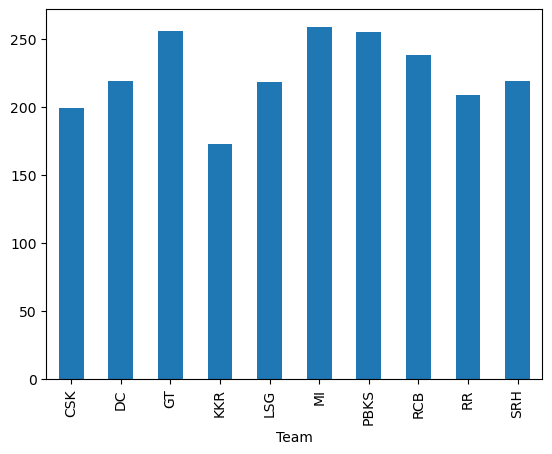

In [32]:
df_batting.groupby('Team')['4s'].sum(numeric_only= True).plot(kind='bar')



In [29]:
df_batting.groupby('Team')['6s'].sum(numeric_only= True)

Team
CSK     102
DC      109
GT      124
KKR     101
LSG     152
MI      142
PBKS    173
RCB     125
RR      146
SRH     120
Name: 6s, dtype: int64

<Axes: xlabel='Team'>

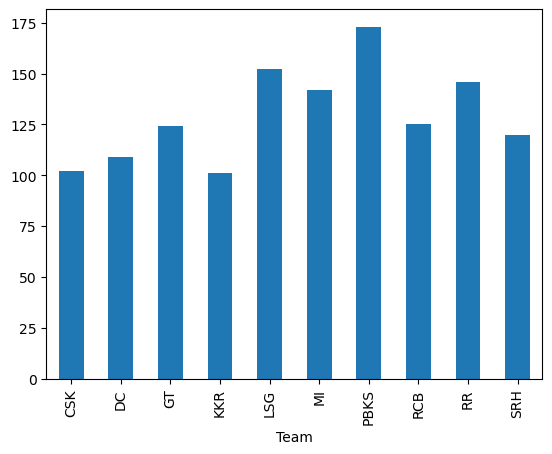

In [27]:
df_batting.groupby('Team')['6s'].sum(numeric_only= True).plot(kind='bar')